# 03. The Bayesian structural time-series model, fitted by ADVI

The generative model is defined once in `nemforecastdemand.models.bsts`
and shared with notebook 04, which marginalises its latent states and
fits it by NUTS on the full training year, so everything that differs
between these notebooks is the inference strategy. On demand
standardised over the fitting window:

$$
\begin{aligned}
y_t &\sim \mathcal{N}\!\left(\ell_t + x_t^\top \beta,\ \sigma_t^2\right),
&\log \sigma_t &= \gamma_0 + z_t^\top \gamma,\\
\ell_t &= \ell_{t-1} + b_{t-1} + \sigma_\ell\, \varepsilon^\ell_t,
&b_t &= \phi\, b_{t-1} + \sigma_b\, \varepsilon^b_t,
\qquad \varepsilon^\ell_t, \varepsilon^b_t \sim \mathcal{N}(0, 1),
\end{aligned}
$$

a stochastic local linear trend with damped slope, static regression on
the shared design $x_t$ (seasonal harmonics on local-clock phases,
temperature, dew point, irradiance, degree days, demand lags, holiday) and
a log-linear observation scale in a small variance design $z_t$ (three
daily harmonics plus degree days), so predictive spread follows the
covariates. Priors are weakly informative on the standardised scale:
half-normal innovation scales (0.1 and 0.01: trend moves slowly at half
hours), Beta(8, 2) damping, unit-scale Gaussian coefficients and tight
Gaussians on the variance head, whose exponential link punishes loose
priors with pathological geometry.

**Parameterisation matters more than priors here.** The innovations enter
as standard normal draws scaled inside the `lax.scan` recursion (the
non-centred form), which removes the funnel coupling the innovation scales
to the states. Sampled state paths plus roughly fifty regression and
variance parameters give a latent space of about 5,400 dimensions.

**ADVI.** Automatic-differentiation variational inference maximises the
evidence lower bound over a Gaussian surrogate $q$ in the unconstrained
space, and the ELBO splits exactly as

$$ \mathrm{ELBO} = \underbrace{\mathbb{E}_q[\log p(y, \theta)]}_{\text{energy}}
   + \underbrace{\mathbb{H}[q]}_{\text{entropy}}, $$

energy rewarding mass where the model has it and entropy rewarding spread
(the energy term absorbs the Jacobian of the constraining transforms; the
entropy of a Gaussian surrogate is closed form). Watching the two parts
separately shows *how* the surrogate converges: under-dispersion appears
as entropy collapsing while energy still climbs.

Only the **mean-field** family (`AutoNormal`, independent Gaussians)
survives this geometry. The **full-rank** alternative
(`AutoMultivariateNormal`), whose covariance could carry the posterior
correlations mean-field must discard, fails here twice over: its
Cholesky factor holds roughly fifteen million entries against 2,688
observations, and at the settings that serve it well on the collapsed
model it diverged to NaN within two hundred optimisation steps, in both
attempts. That failure is reported below as a finding; the two-family
comparison happens on the collapsed formulation in notebook 04, where
the full covariance is a well-determined fifty-by-fifty object.

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")  # notebook JAX work is light; leave the GPU to fits

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nemforecastdemand.config import load_config
from nemforecastdemand.data.loaders import load_splits
from nemforecastdemand.evaluation.metrics import crps_gaussian, crps_samples
from nemforecastdemand.models import bsts
from nemforecastdemand.plotting import fan_chart, palette, save_figure, setup_style
from nemforecastdemand.splits import rolling_origins
from nemforecastdemand.utils import load_artifact

setup_style()
cfg = load_config()
splits = load_splits(cfg.paths.processed)
panel = pd.concat([splits["train"], splits["validation"], splits["test"]])

fits = {kind: load_artifact(cfg.paths.artifacts / f"bsts_vi_{kind}") for kind in ("meanfield",)}
test_origins = rolling_origins(
    splits["test"].index, panel.index, cfg.origins, cfg.horizon, max(cfg.features.demand_lags)
)

/home/s95717/miniforge3/envs/nem-demand-forecast/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## ELBO convergence, decomposed

The surrogate is optimised with Adam (20,000 steps, exponentially
decayed learning rate, gradient clipping); the ELBO is re-estimated with
64 particles at every checkpoint so the curves below are not just
single-sample noise.

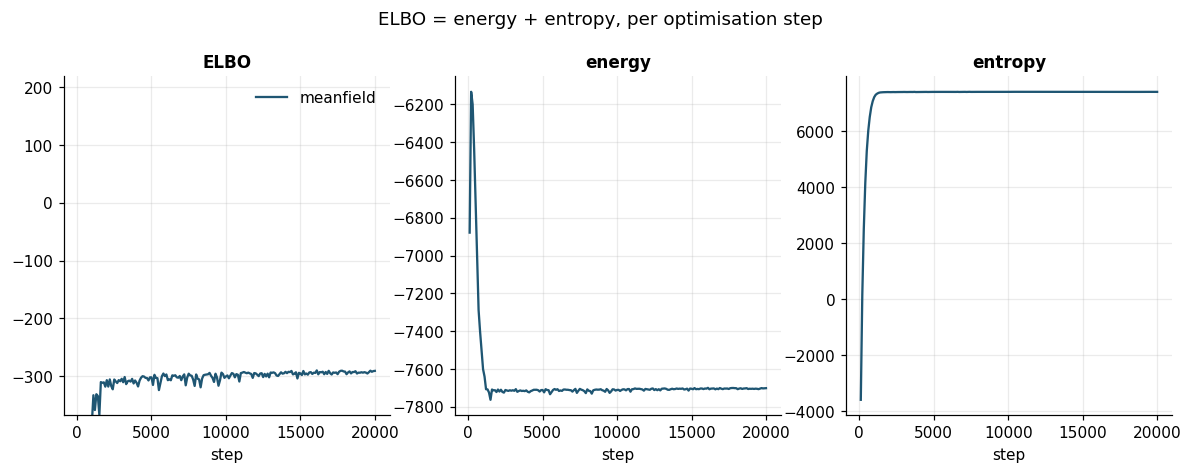

,final ELBO,final entropy,"plateau drift, last 2k steps",fit seconds,steps per second,device
meanfield,-290.983582,7410.160156,0.07%,861.149908,23.223599,gpu


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colours = {"meanfield": palette("demand"), "fullrank": palette("accent")}
for kind, (arrays, _meta) in fits.items():
    axes[0].plot(arrays["elbo_steps"], arrays["elbo"], color=colours[kind], label=kind)
    axes[1].plot(arrays["elbo_steps"], arrays["energy"], color=colours[kind])
    axes[2].plot(arrays["elbo_steps"], arrays["entropy"], color=colours[kind])
for ax, title in zip(axes, ("ELBO", "energy", "entropy"), strict=True):
    ax.set_title(title)
    ax.set_xlabel("step")
axes[0].set_ylim(bottom=np.quantile(fits["meanfield"][0]["elbo"], 0.05))
axes[0].legend()
fig.suptitle("ELBO = energy + entropy, per optimisation step", y=1.03)
save_figure(fig, "elbo_decomposition", cfg.paths.figures)
plt.show()


def plateau_drift(elbo: np.ndarray, window: int = 20) -> str:
    """Relative ELBO drift between the last two checkpoint windows."""
    recent = elbo[-window:].mean()
    previous = elbo[-2 * window : -window].mean()
    return f"{abs(recent - previous) / abs(previous):.2%}"


pd.DataFrame(
    {
        kind: {
            "final ELBO": meta["final_elbo"],
            "final entropy": meta["final_entropy"],
            "plateau drift, last 2k steps": plateau_drift(arrays["elbo"]),
            "fit seconds": meta["timings_seconds"]["fit_seconds"],
            "steps per second": meta["timings_seconds"]["steps_per_second"],
            "device": meta["device"],
        }
        for kind, (arrays, meta) in fits.items()
    }
).T

The decomposition is the diagnostic the single ELBO number hides: a
factorised Gaussian pays for ignored correlations with shrunken
marginals, which appears as entropy settling low while energy still
climbs. Whether this mean-field posterior is too tight cannot be settled
on this formulation, because nothing better is available here to compare
against; notebook 04 settles it on the collapsed model.

## Where the other inference paths stop

This geometry is the project's stress test, and the mean-field guide is
the only fit that survives it.

- **NUTS (cold)**: stopped after seventeen hours on the GPU without
  completing its 2,000 iterations; depth-10 trajectories cost up to
  1,023 gradient evaluations per iteration per chain, each one
  back-propagated through the 2,688-step scan. Notebook 04 opens with
  this finding.
- **Full-rank ADVI**: diverged to NaN within two hundred steps, twice,
  at the settings that serve the same family well on the collapsed
  model (ELBO roughly -30,000 at step 100, NaN by step 200). The deeper
  objection stands even if tighter settings were found: a dense
  Cholesky factor of roughly fifteen million entries estimated from
  2,688 observations with an eight-particle gradient would be
  underdetermined regardless of whether it optimised.

What rescues both is the same marginalisation: on the collapsed
formulation the latent states integrate out exactly, the full-rank
covariance becomes a well-determined fifty-dimensional object and NUTS
certifies the posterior in minutes. The inference adjudication
therefore lives in notebook 04; this notebook carries the surviving
fit forward.

## The fitted trend and the learned variance profile

The level component absorbs what the regression cannot explain: slow
drift in the demand baseline. The variance head learns the daily rhythm
of predictability, narrow bands in the small hours and wide bands across
the afternoon and evening, which is exactly what the homoskedastic
baseline could not express.

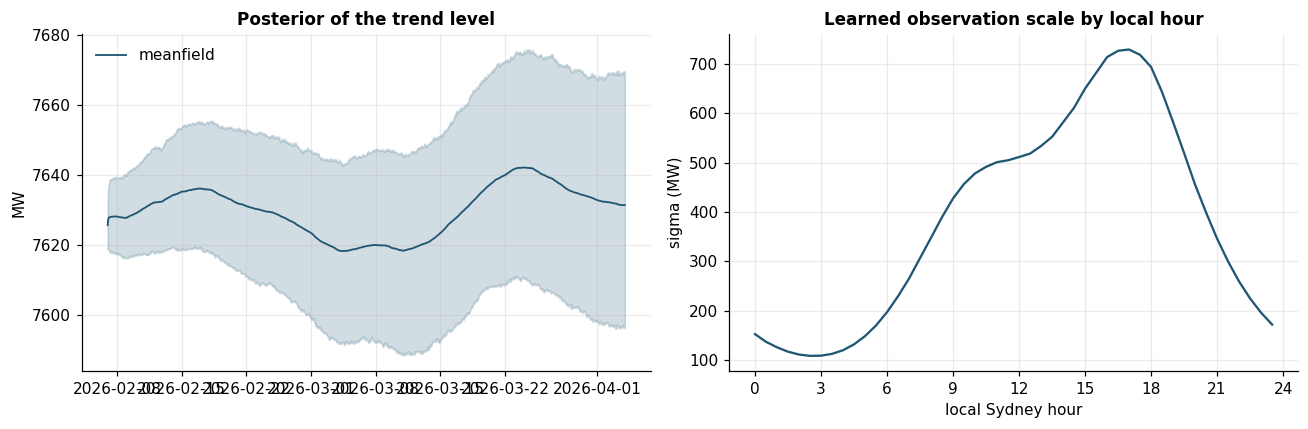

In [3]:
fit_index = panel.index[panel.index < splits["test"].index[0]][-cfg.bsts.train_days * 48 :]
inputs = bsts.prepare_inputs(panel, cfg, fit_index)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for kind, (arrays, _meta) in fits.items():
    level_mw = arrays["level_mean"] * inputs.y_scale + inputs.y_loc
    band_lo = arrays["level_q05"] * inputs.y_scale + inputs.y_loc
    band_hi = arrays["level_q95"] * inputs.y_scale + inputs.y_loc
    times = fit_index.tz_convert("Australia/Brisbane")
    axes[0].plot(times, level_mw, color=colours[kind], lw=1.2, label=kind)
    axes[0].fill_between(times, band_lo, band_hi, color=colours[kind], alpha=0.2)
axes[0].set_title("Posterior of the trend level")
axes[0].set_ylabel("MW")
axes[0].legend()

local_hour = fit_index.tz_convert("Australia/Sydney")
hour_frac = local_hour.hour + local_hour.minute / 60
for kind, (arrays, _meta) in fits.items():
    gamma0 = arrays["draw_gamma0"][:, None]
    gamma = arrays["draw_gamma"]
    log_sigma = gamma0 + gamma @ inputs.x_var.T
    sigma_mw = np.exp(log_sigma) * inputs.y_scale
    profile = (
        pd.DataFrame({"hour": hour_frac, "sigma": sigma_mw.mean(axis=0)}).groupby("hour").mean()
    )
    axes[1].plot(profile.index, profile["sigma"], color=colours[kind], label=kind)
axes[1].set_title("Learned observation scale by local hour")
axes[1].set_xlabel("local Sydney hour")
axes[1].set_ylabel("sigma (MW)")
axes[1].set_xticks(np.arange(0, 25, 3))
fig.tight_layout()
save_figure(fig, "bsts_trend_and_variance", cfg.paths.figures)
plt.show()

## Posterior predictive forecasts

Forecasts are Rao-Blackwellised: conditional on each hyperparameter draw
the model is linear-Gaussian, so a Kalman filter conditions on all demand
up to each origin and the horizon is then simulated forward, one jointly
coherent 48-step path per posterior draw. CRPS uses the energy-form
sample estimator (unit-tested against the analytic Gaussian form used for
the baseline).

In [4]:
arima_arrays, arima_meta = load_artifact(cfg.paths.artifacts / "arima")
y_test = fits["meanfield"][0]["y_test"]

crps_rows = {}
for kind, (arrays, _meta) in fits.items():
    per_origin = np.stack(
        [
            crps_samples(y_test[i], arrays["forecast_paths"][:, i, :]).mean()
            for i in range(y_test.shape[0])
        ]
    )
    crps_rows[f"BSTS ADVI {kind}"] = per_origin.mean()
crps_rows["ARIMA baseline (same 56-day window)"] = float(
    crps_gaussian(
        arima_arrays["y_test"], arima_arrays["forecast_mean"], arima_arrays["forecast_sd"]
    ).mean()
)
pd.Series(crps_rows, name="test CRPS (MW), archived forecast weather").to_frame().round(1)

,"test CRPS (MW), archived forecast weather"
BSTS ADVI meanfield,364.1
ARIMA baseline (same 56-day window),301.2


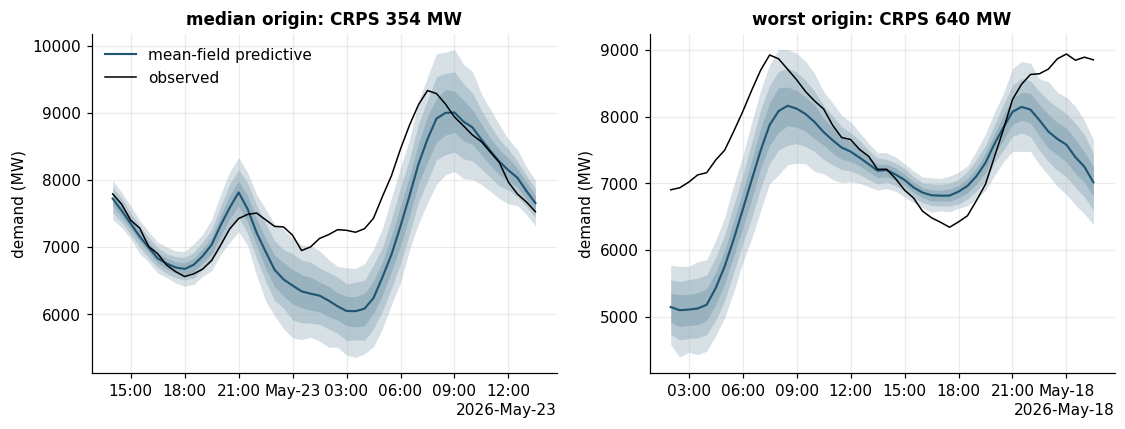

In [5]:
mf_paths = fits["meanfield"][0]["forecast_paths"]
daily_crps = np.stack(
    [crps_samples(y_test[i], mf_paths[:, i, :]).mean() for i in range(y_test.shape[0])]
)
typical = int(np.argsort(daily_crps)[len(daily_crps) // 2])
worst = int(daily_crps.argmax())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pos, title in ((axes[0], typical, "median origin"), (axes[1], worst, "worst origin")):
    origin = test_origins[pos]
    index = pd.date_range(origin, periods=cfg.horizon, freq="30min")
    fan_chart(
        ax,
        index,
        samples=mf_paths[:, pos, :],
        colour=palette("demand"),
        label="mean-field predictive",
    )
    ax.plot(
        index.tz_convert("Australia/Brisbane"), y_test[pos], color="black", lw=1.0, label="observed"
    )
    ax.set_title(f"{title}: CRPS {daily_crps[pos]:.0f} MW")
    ax.set_ylabel("demand (MW)")
axes[0].legend()
save_figure(fig, "bsts_vi_fan_charts", cfg.paths.figures)
plt.show()

## Aleatoric against epistemic uncertainty

Because the model is linear-Gaussian given a hyperparameter draw, the
predictive variance splits exactly (law of total variance) into four
named sources: **parameter** (posterior spread of the per-draw
predictive means) and **state** (how well the level and slope at the
origin are pinned down) are epistemic, shrinking with more data;
**process** (future trend innovations) and **observation** (the
heteroskedastic noise floor) are aleatoric, irreducible under the model.
The split is computed analytically per draw, no simulation involved.

The fractions are diagnostic for the inference comparison too: a
surrogate that under-states posterior spread must report a smaller
epistemic share. Whether this mean-field fit does is exactly what the
NUTS adjudication on the collapsed model in notebook 04 makes precise.

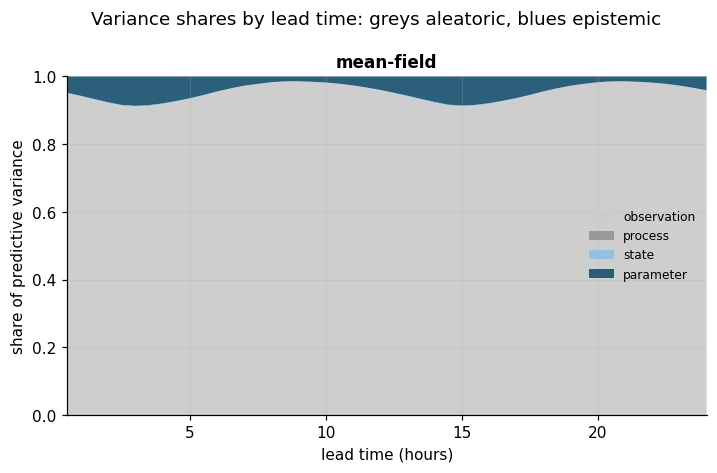

In [6]:
from nemforecastdemand.models.predict import variance_decomposition

decomp = {}
for kind, (arrays, _meta) in fits.items():
    draws = {site: arrays[f"draw_{site}"] for site in bsts.HYPER_SITES}
    decomp[kind] = variance_decomposition(draws, inputs, panel, cfg, test_origins)

component_order = ["observation", "process", "state", "parameter"]
component_colours = {
    "observation": "#cccccc",
    "process": "#969696",
    "state": "#8fc1e3",
    "parameter": "#1f5673",
}
hours = (np.arange(cfg.horizon) + 1) / 2
fig, ax = plt.subplots(figsize=(7.5, 4))
parts = decomp["meanfield"]
total = sum(parts.values())
shares = np.stack([(parts[name] / total).mean(axis=0) for name in component_order])
ax.stackplot(
    hours,
    shares,
    labels=component_order,
    colors=[component_colours[n] for n in component_order],
    alpha=0.95,
)
ax.set_title("mean-field")
ax.set_xlabel("lead time (hours)")
ax.set_ylim(0, 1)
ax.set_xlim(hours[0], hours[-1])
ax.set_ylabel("share of predictive variance")
ax.legend(loc="center right", fontsize=8)
fig.suptitle("Variance shares by lead time: greys aleatoric, blues epistemic", y=1.03)
save_figure(fig, "bsts_vi_variance_decomposition", cfg.paths.figures)
plt.show()

In [7]:
rows = {}
for kind in fits:
    parts = decomp[kind]
    total = sum(parts.values())
    rows[kind] = {f"{name} share": float((parts[name] / total).mean()) for name in component_order}
    rows[kind]["epistemic share"] = rows[kind]["state share"] + rows[kind]["parameter share"]
    rows[kind]["mean predictive sd (MW)"] = float(np.sqrt(total.mean()))
pd.DataFrame(rows).T.round(3)

,observation share,process share,state share,parameter share,epistemic share,mean predictive sd (MW)
meanfield,0.952,0.0,0.001,0.046,0.048,362.117


The allocation is striking: this fit attributes about 95% of its
predictive variance to the observation-noise floor and essentially none
to future trend innovations, because its posterior pushes the
innovation scales towards zero. Taken at face value that says the trend
is nearly deterministic and almost nothing would be gained by more
data. But if the surrogate under-estimates those scales, the same
decomposition under the reference posterior should move variance into
the process and parameter shares, and notebook 04 runs exactly that
check on the collapsed model.

## Cost

Fit and forecast wall-clock per surrogate (the forecast time covers all
112 origins under all six weather variants, dominated by the one-off
Kalman filter pass over the posterior).

In [8]:
pd.DataFrame(
    {
        kind: {
            "fit (s)": meta["timings_seconds"]["fit_seconds"],
            "compile (s)": meta["timings_seconds"]["compile_seconds"],
            "forecast, all origins and variants (s)": meta["timings_seconds"]["predict_seconds"],
            "device": meta["device"],
        }
        for kind, (arrays, meta) in fits.items()
    }
).T

,fit (s),compile (s),"forecast, all origins and variants (s)",device
meanfield,861.149908,2.264155,5.672193,gpu


## Summary

- The mean-field surrogate optimises cleanly on a 5,400-dimensional
  geometry and is the only inference path that survives it: cold NUTS
  was stopped after seventeen hours and the full-rank factor diverged
  twice, both documented above as findings rather than worked around.
- The heteroskedastic head learns a plausible daily risk profile, and
  the exact variance decomposition names where predictive uncertainty
  comes from at each lead time.
- Predictively the fit clears the seasonal-naive floor (364 against 374
  MW CRPS) but trails the matched-window classical baseline (301 MW):
  imposed structure does not pay for the short window on this task.
  What more data and exact marginalisation buy the same model is the
  question notebooks 04 and 05 answer.
- Whether this posterior is too tight cannot be judged here, because no
  reference posterior exists on this formulation; the adjudication runs
  against collapsed NUTS in notebook 04.